In [120]:
import copy
from pathlib import Path
import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pytagi import Normalizer
import pytagi.metric as metric
from pytagi import Normalizer as normalizer
from canari import (
    DataProcess,
    Model,
    ModelOptimizer,
    SKF,
    SKFOptimizer,
    plot_data,
    plot_prediction,
    plot_skf_states,
    plot_states,
)
from canari.component import LocalTrend, LocalAcceleration, LstmNetwork, WhiteNoise


In [121]:
# data_file = "/Users/vuongdai/Desktop/backup_canari/TDSB_data/LGA/LGABAR/EXT/LGA010ESAPRG988.DAT"
data_file = "/Users/vuongdai/Desktop/backup_canari/TDSB_data/LTU/LTUBAR/PEN/ST/LTU014PIAEVA920.DAT"
df_raw = pd.read_csv(data_file,
                     sep=";",  # Semicolon as delimiter
                     quotechar='"',
                     engine="python",
                     na_values=[""],  # Treat empty strings as NaN
                     skipinitialspace=True,
                     encoding="ISO-8859-1",
                     )

In [122]:
df_raw.head()

,No pendule,Amenagement,Ouvrage,Date,Nombre Date,Niveau Reservoir (m),Deplacements cumulatif X (mm),Deplacements cumulatif Y (mm),Deplacements cumulatif Z (mm),Remarque,...,Unnamed: 30,Unnamed: 31,Unnamed: 32,Unnamed: 33,Unnamed: 34,Unnamed: 35,Unnamed: 36,Unnamed: 37,Unnamed: 38,Unnamed: 39
0,LTU014PIAEVA920,LTU,LTUBAR,2002-12-06 00:00,37596.0,151.74,-3.02,-0.70,2.35,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,LTU014PIAEVA920,LTU,LTUBAR,2002-12-07 00:00,37597.0,151.78,-3.02,-0.58,2.33,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,LTU014PIAEVA920,LTU,LTUBAR,2002-12-08 00:00,37598.0,151.57,-2.98,-0.63,2.30,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,LTU014PIAEVA920,LTU,LTUBAR,2002-12-09 00:00,37599.0,151.28,-3.04,-0.50,2.26,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,LTU014PIAEVA920,LTU,LTUBAR,2002-12-10 00:00,37600.0,151.36,-3.05,-0.41,2.21,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [123]:
# df = df_raw[["Ext/Contraction (mm)"]]
df = df_raw[["Deplacements cumulatif X (mm)"]]

df.columns = ["ext"]
df.index = pd.to_datetime(df_raw["Date"])
# Resampling to weekly
df = df.resample("W").last()

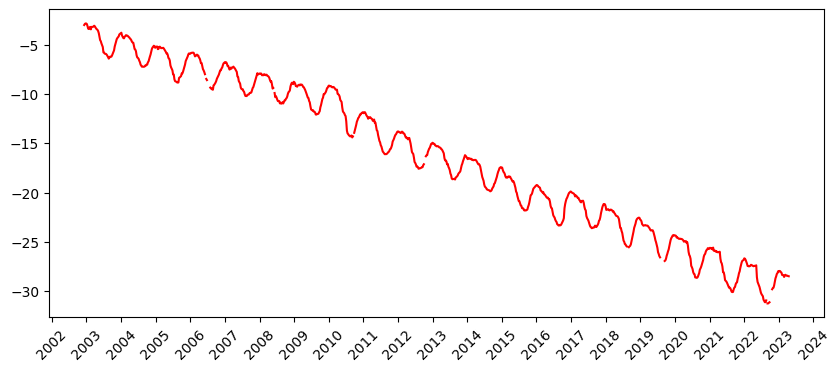

In [124]:
import matplotlib.dates as mdates
fig, ax = plt.subplots(figsize=(10, 4))
plt.plot(df.index, df["ext"], color="red")
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.xticks(rotation=45)
plt.show()

In [125]:
# Data pre-processing
output_col = [0]
scale_const_mean = np.nanmean(df["ext"].iloc[0:52*2])
scale_const_std = np.nanstd(df["ext"].iloc[0:52*2])
data_processor = DataProcess(
    data=df,
    time_covariates=["week_of_year"],
    train_split=0.2,
    validation_split=0.08,
    test_split=0.67,
    output_col=output_col,
    scale_const_mean=[scale_const_mean, 26.95754717],
    scale_const_std=[scale_const_std, 15.22916423],
)
train_data, validation_data, test_data, all_data = data_processor.get_splits()
seed = np.random.randint(0, 100)

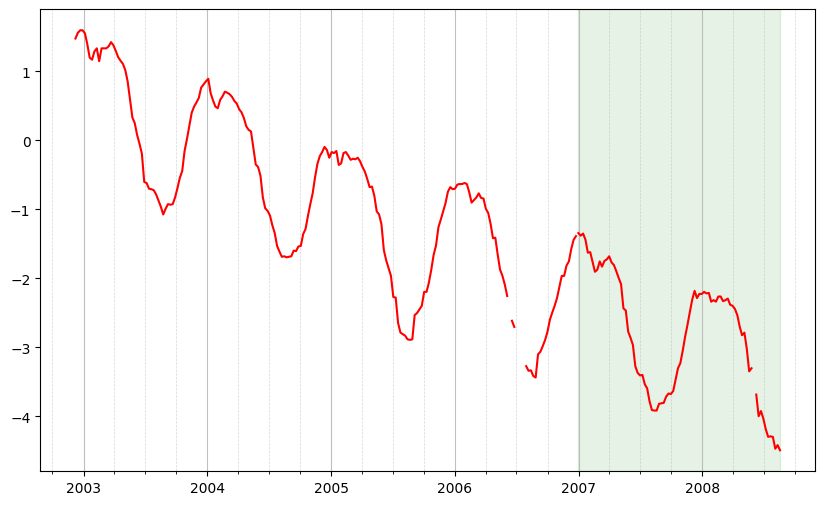

In [126]:
fig, ax = plt.subplots(figsize=(10, 6))
plot_data(
    data_processor=data_processor,
    plot_column=output_col,
    standardization=True,
    plot_test_data=False,
    sub_plot=ax,
    validation_label="y",
)

In [127]:
param_optimization = True
smoother = True
num_trial_optim_model = 50

In [128]:
######### Define model with parameters #########
def model_with_parameters(param, train_data, validation_data):
    model = Model(
        LocalTrend(),
        LstmNetwork(
            look_back_len=param["look_back_len"],
            num_features=2,
            num_layer=1,
            infer_len=52 * 3,
            num_hidden_unit=50,
            manual_seed=seed,
            smoother=smoother,
        ),
        WhiteNoise(std_error=param["sigma_v"]),
    )

    model.auto_initialize_baseline_states(train_data["y"][0 : 52 * 3])
    num_epoch = 50
    for epoch in range(num_epoch):
        mu_validation_preds, std_validation_preds, _ = model.lstm_train(
            train_data=train_data,
            validation_data=validation_data,
        )

        mu_validation_preds_unnorm = normalizer.unstandardize(
            mu_validation_preds,
            data_processor.scale_const_mean[data_processor.output_col],
            data_processor.scale_const_std[data_processor.output_col],
        )

        std_validation_preds_unnorm = normalizer.unstandardize_std(
            std_validation_preds,
            data_processor.scale_const_std[data_processor.output_col],
        )

        validation_obs = data_processor.get_data("validation").flatten()
        validation_log_lik = metric.log_likelihood(
            prediction=mu_validation_preds_unnorm,
            observation=validation_obs,
            std=std_validation_preds_unnorm,
        )

        model.early_stopping(
            evaluate_metric=-validation_log_lik,
            current_epoch=epoch,
            max_epoch=num_epoch,
        )
        model.metric_optim = model.early_stop_metric

        if model.stop_training:
            break

    #### Define SKF model with parameters #########

    abnorm_model = Model(
        LocalAcceleration(),
        LstmNetwork(),
        WhiteNoise(),
    )
    skf = SKF(
        norm_model=model,
        abnorm_model=abnorm_model,
        std_transition_error=1e-4,
        norm_to_abnorm_prob=1e-5,
    )

    skf.save_initial_states()

    filter_marginal_abnorm_prob, states, mu_preds, std_preds = skf.filter(
        data=all_data
    )

    mu_preds_unnorm = normalizer.unstandardize(
        mu_preds,
        data_processor.scale_const_mean[data_processor.output_col],
        data_processor.scale_const_std[data_processor.output_col],
    )

    std_preds_unnorm = normalizer.unstandardize_std(
        std_preds,
        data_processor.scale_const_std[data_processor.output_col],
    )

    obs_all = data_processor.get_data("all").flatten()
    log_lik_all = metric.log_likelihood(
        prediction=mu_preds_unnorm,
        observation=obs_all,
        std=std_preds_unnorm,
    )
    skf.metric_optim = -log_lik_all

    skf.load_initial_states()

    return skf, filter_marginal_abnorm_prob, states

#  1/50 - Metric: 0.378 - Parameter: {'look_back_len': 32, 'sigma_v': 0.19948613154165423}
#  2/50 - Metric: 0.304 - Parameter: {'look_back_len': 23, 'sigma_v': 0.15984961098793998}
#  3/50 - Metric: 0.348 - Parameter: {'look_back_len': 24, 'sigma_v': 0.13144145574621746}
#  4/50 - Metric: 0.357 - Parameter: {'look_back_len': 41, 'sigma_v': 0.07684139885813925}
#  5/50 - Metric: 0.322 - Parameter: {'look_back_len': 23, 'sigma_v': 0.09991094839905423}
#  6/50 - Metric: 0.406 - Parameter: {'look_back_len': 41, 'sigma_v': 0.06861571098835254}
#  7/50 - Metric: 1.497 - Parameter: {'look_back_len': 50, 'sigma_v': 0.12285029875304537}
#  8/50 - Metric: 0.419 - Parameter: {'look_back_len': 35, 'sigma_v': 0.08081564094004909}
#  9/50 - Metric: 0.344 - Parameter: {'look_back_len': 26, 'sigma_v': 0.02045302625239695}
# 10/50 - Metric: 0.375 - Parameter: {'look_back_len': 15, 'sigma_v': 0.040225389057731646}
# 11/50 - Metric: 0.321 - Parameter: {'look_back_len': 18, 'sigma_v': 0.1205251106493548}

2025-11-18 13:59:08,953	INFO tune.py:1009 -- Wrote the latest version of all result files and experiment state to '/Users/vuongdai/ray_results/Model_optimizer' in 0.0166s.


# 50/50 - Metric: 0.248 - Parameter: {'look_back_len': 12, 'sigma_v': 0.13051672068622555}
-----
Optimal parameters at trial #43: {'look_back_len': 14, 'sigma_v': 0.1318303868589762}
-----


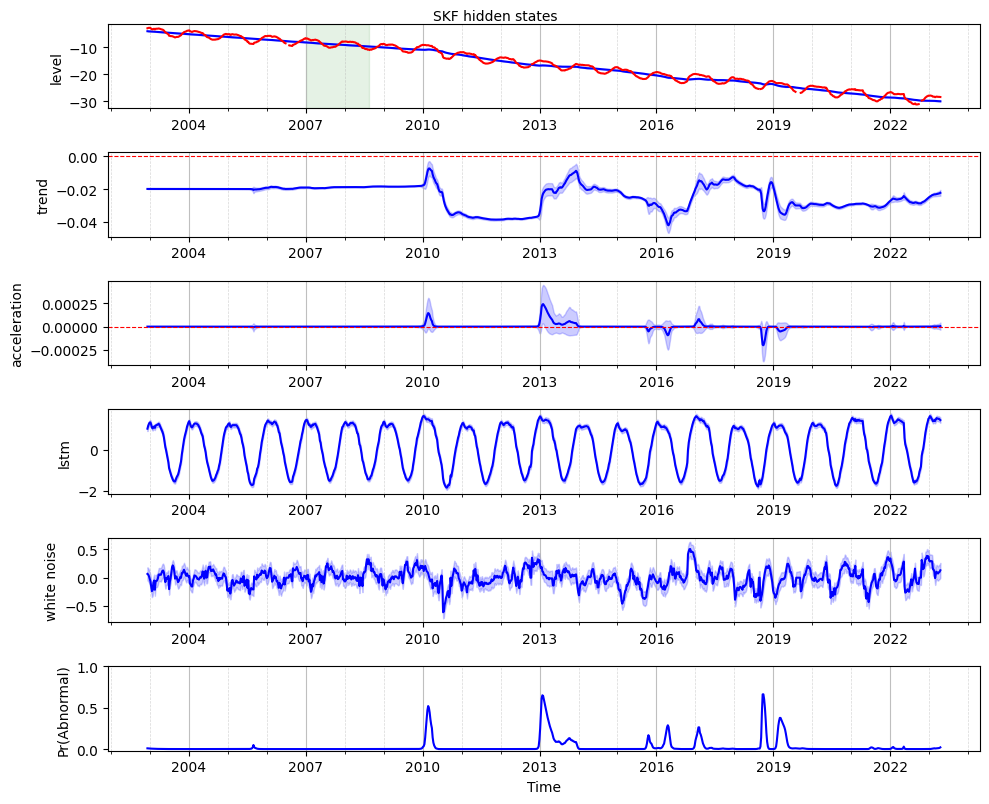

In [130]:
if param_optimization:
    param_space = {
        "look_back_len": [12, 52],
        "sigma_v": [1e-3, 2e-1],
    }
    # Define optimizer
    model_optimizer = ModelOptimizer(
        model=model_with_parameters,
        param_space=param_space,
        train_data=train_data,
        validation_data=validation_data,
        num_optimization_trial=num_trial_optim_model,
    )
    model_optimizer.optimize()
    # Get best model
    param = model_optimizer.get_best_param()
    skf_optim, filter_marginal_abnorm_prob, states = model_with_parameters(
        param, train_data, validation_data
    )

    skf_optim_dict = skf_optim.get_dict()
    skf_optim_dict["model_param"] = param
    skf_optim_dict["cov_names"] = train_data["cov_names"]
    with open("/Users/vuongdai/GitHub/canari/saved_params/benchmark_14_LL.pkl", "wb") as f:
        pickle.dump(skf_optim_dict, f)
else:
    with open("/Users/vuongdai/GitHub/canari/saved_params/benchmark_14_LL.pkl", "rb") as f:
        skf_optim_dict = pickle.load(f)
    skf_optim = SKF.load_dict(skf_optim_dict)

filter_marginal_abnorm_prob, states, *_ = skf_optim.filter(data=all_data)
smooth_marginal_abnorm_prob, states = skf_optim.smoother()

fig, ax = plot_skf_states(
    data_processor=data_processor,
    states=states,
    model_prob=filter_marginal_abnorm_prob,
)
fig.suptitle("SKF hidden states", fontsize=10, y=1)
plt.savefig("/Users/vuongdai/GitHub/canari/saved_results/BM14.png")
plt.show()